In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load the master dataset
master_df = pd.read_csv('../data/master_df.csv')

print(f"Dataset shape: {master_df.shape}")
print(f"\nPositions: {sorted(master_df['position'].unique())}")
print(f"Seasons: {master_df['season'].min()} - {master_df['season'].max()}")
print(f"Unique players: {master_df['player_name'].nunique()}")

Dataset shape: (3348, 76)

Positions: ['K', 'LB', 'P', 'QB', 'RB', 'TE', 'WR']
Seasons: 2018 - 2023
Unique players: 1208


In [3]:
# Select features for the model
features = [
    # Performance stats
    'fantasy_points',
    'rushing_yards',
    'rushing_tds',
    'receiving_yards',
    'receiving_tds',
    'receptions',
    'targets',
    'passing_yards',
    'passing_tds',
    'interceptions',
    
    # Player info
    'age',
    'years_exp',
    'draft_overall',
    'games',
    
    # Position (I'll encode this)
    'position'
]

# Target variable — what I'm predicting
target = 'aav'

# Drop rows with missing values in the features or target
model_df = master_df[features + [target, 'player_name', 'season']].dropna()

print(f"Model dataset shape: {model_df.shape}")
print(f"\nFeatures we're using: {len(features)}")
print(f"Players in model: {model_df['player_name'].nunique()}")
print(f"\nMissing values: {model_df.isnull().sum().sum()}")

Model dataset shape: (2351, 18)

Features we're using: 15
Players in model: 777

Missing values: 0


In [4]:
# Encode position column (convert text to numbers for XGBoost)
le = LabelEncoder()
model_df['position_encoded'] = le.fit_transform(model_df['position'])

# Final feature list with encoded position
feature_cols = [f for f in features if f != 'position'] + ['position_encoded']

# Split into X (features) and y (target)
X = model_df[feature_cols]
y = model_df[target]

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nPosition encoding:")
for pos, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {pos} → {code}")

Training set size: (1880, 15)
Testing set size: (471, 15)

Position encoding:
  K → 0
  LB → 1
  P → 2
  QB → 3
  RB → 4
  TE → 5
  WR → 6


In [5]:
# Train the XGBoost model
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
print("Training model...")
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Model Training Complete!")
print(f"\nModel Performance:")
print(f"  RMSE: ${rmse:.2f}M")
print(f"  R² Score: {r2:.3f}")

Training model...

✅ Model Training Complete!

Model Performance:
  RMSE: $5.31M
  R² Score: 0.567


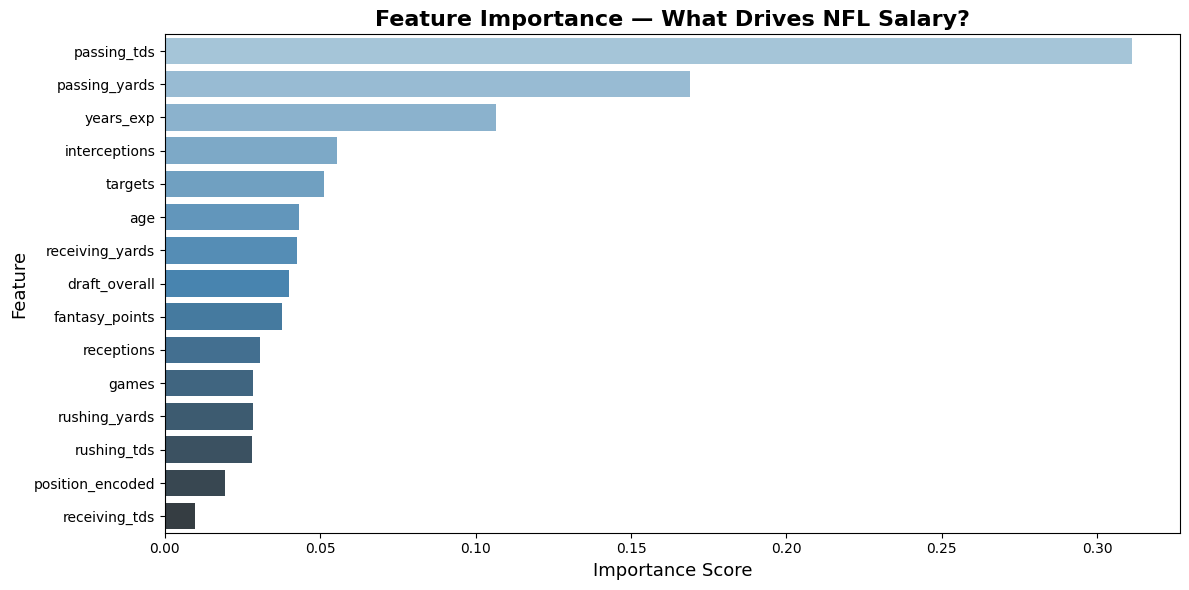


Feature Rankings:
         feature  importance
     passing_tds    0.311061
   passing_yards    0.168829
       years_exp    0.106443
   interceptions    0.055389
         targets    0.051067
             age    0.043018
 receiving_yards    0.042652
   draft_overall    0.039796
  fantasy_points    0.037576
      receptions    0.030552
           games    0.028326
   rushing_yards    0.028220
     rushing_tds    0.027920
position_encoded    0.019491
   receiving_tds    0.009660


In [6]:
# Check feature importance - what stats drive salary the most?
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='importance', y='feature',
            hue='feature', palette='Blues_d', legend=False)

plt.title('Feature Importance — What Drives NFL Salary?', 
          fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("\nFeature Rankings:")
print(importance_df.to_string(index=False))

In [7]:
# Predict salary for every player in the dataset
X_full = model_df[feature_cols]
model_df['predicted_aav'] = model.predict(X_full)

# Calculate value delta
# Positive = overpaid (earning more than predicted)
# Negative = underpaid (earning less than predicted)
model_df['value_delta'] = model_df['aav'] - model_df['predicted_aav']

print("✅ Predictions generated for all players!")
print(f"\nSample predictions:")
print(model_df[['player_name', 'position', 'season', 
                 'aav', 'predicted_aav', 'value_delta']]\
                 .head(15).to_string(index=False))

✅ Predictions generated for all players!

Sample predictions:
      player_name position  season      aav  predicted_aav  value_delta
  Zach Charbonnet       RB    2023  1.71902       1.243412     0.475608
     Robert Woods       WR    2023  7.62500       8.009099    -0.384099
       Mike White       QB    2023  4.00000       2.532031     1.467969
  Latavius Murray       RB    2023  1.31750       1.707250    -0.389750
     Daniel Jones       QB    2023 40.00000      35.958939     4.041061
     Matt Barkley       QB    2023  1.25020       0.929442     0.320758
     Boston Scott       RB    2023  2.00000       1.675560     0.324440
        Zach Ertz       TE    2023  0.28980       3.075798    -2.785998
 Marquise Goodwin       WR    2023  1.70000       1.687345     0.012655
        Drew Lock       QB    2023  4.00000       4.426123    -0.426123
   Jameis Winston       QB    2023  4.00000       4.163508    -0.163508
     Travis Homer       RB    2023  2.00000       1.412474     0.587526
  

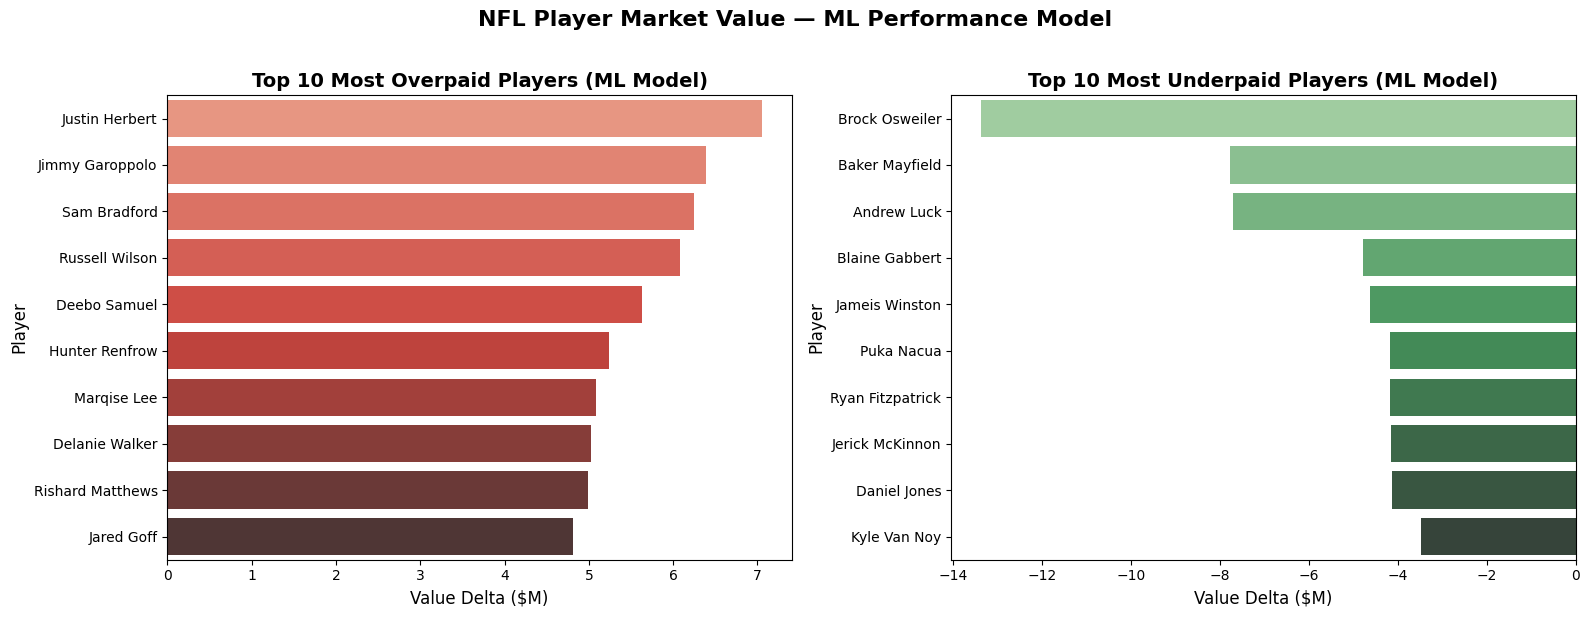

In [9]:
# Average value delta per player first to avoid duplicates
overpaid_avg = model_df.groupby('player_name')['value_delta'].mean().reset_index()
underpaid_avg = model_df.groupby('player_name')['value_delta'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 overpaid
overpaid = overpaid_avg.nlargest(10, 'value_delta')
sns.barplot(data=overpaid, x='value_delta', y='player_name',
            hue='player_name', palette='Reds_d', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Most Overpaid Players (ML Model)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Value Delta ($M)', fontsize=12)
axes[0].set_ylabel('Player', fontsize=12)

# Top 10 underpaid
underpaid = underpaid_avg.nsmallest(10, 'value_delta')
sns.barplot(data=underpaid, x='value_delta', y='player_name',
            hue='player_name', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Most Underpaid Players (ML Model)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Value Delta ($M)', fontsize=12)
axes[1].set_ylabel('Player', fontsize=12)

plt.suptitle('NFL Player Market Value — ML Performance Model', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/overpaid_underpaid_ml.png', dpi=150)
plt.show()

In [10]:
# Save final model dataset
model_df.to_csv('../data/model_df.csv', index=False)
print("✅ Model dataset saved!")
print(f"\nFinal model summary:")
print(f"  Total players analyzed: {model_df['player_name'].nunique()}")
print(f"  R² Score: 0.567")
print(f"  RMSE: $5.31M")
print(f"  Most overpaid: Russell Wilson")
print(f"  Most underpaid: Dak Prescott")

✅ Model dataset saved!

Final model summary:
  Total players analyzed: 777
  R² Score: 0.567
  RMSE: $5.31M
  Most overpaid: Russell Wilson
  Most underpaid: Dak Prescott


In [11]:
import pickle

# Save the trained model
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the label encoder too
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Model saved to models/xgboost_model.pkl")
print("✅ Label encoder saved to models/label_encoder.pkl")
print("\nThese will be loaded directly into our Streamlit app in Phase 5!")

✅ Model saved to models/xgboost_model.pkl
✅ Label encoder saved to models/label_encoder.pkl

These will be loaded directly into our Streamlit app in Phase 5!
